# Lab Session 1: Implement A* Search Algorithm

**Course:** AI & ML (CS2227)  
**Module:** 1 – Foundations of Artificial Intelligence  

---

This lab is **fully interactive**. Execute each cell step-by-step and observe how the A* algorithm makes decisions.


## 🎯 Learning Objectives
By the end of this lab, you will be able to:
- Understand problem-solving as a search process
- Explain informed search and heuristics
- Compute g(n), h(n), and f(n)
- Trace A* step-by-step
- Implement A* Search in Python


## 1. Problem Solving as Search
Many AI problems can be framed as **search problems**.

A search problem consists of:
- Initial State
- Goal State
- State Space
- Actions
- Cost


## 2. Heuristic Function h(n)
A heuristic is an **estimate** of the cost from a node to the goal.

It guides the search but does **not guarantee correctness** by itself.


## 3. A* Evaluation Function

\[
f(n) = g(n) + h(n)
\]

- g(n): cost from start to current node  
- h(n): estimated cost to goal  
- f(n): estimated total solution cost


## 4. Problem Definition

We use the following graph:

Start: S  
Goal: G  

Edges:
- S → A (2)
- S → B (5)
- A → G (10)
- B → G (4)

Heuristics:
- h(S)=7, h(A)=6, h(B)=2, h(G)=0


In [ ]:
# Graph representation
graph = {
    'S': [('A', 2), ('B', 5)],
    'A': [('G', 10)],
    'B': [('G', 4)],
    'G': []
}

heuristic = {
    'S': 7,
    'A': 6,
    'B': 2,
    'G': 0
}

print("Graph and heuristic initialized.")

Graph and heuristic initialized.


## 5. Manual A* Trace (Conceptual)

From S:
- A → f = 2 + 6 = 8
- B → f = 5 + 2 = 7

Choose B (lowest f)

From B:
- G → f = 9

Goal reached.
Optimal Path: S → B → G
Total Cost: 9


## 6. A* Algorithm – Python Implementation
The code below prints each expansion so you can **see the algorithm thinking**.


In [ ]:
import heapq

def a_star_search(graph, heuristic, start, goal):
    open_list = []
    heapq.heappush(open_list, (heuristic[start], start))

    g_cost = {start: 0}
    parent = {start: None}
    closed_set = set()

    step = 1

    while open_list:
        f_current, current = heapq.heappop(open_list)

        print(f"Step {step}: Expanding {current}")
        print(f"  g({current}) = {g_cost[current]}")
        print(f"  h({current}) = {heuristic[current]}")
        print(f"  f({current}) = {f_current}")
        print("-" * 30)

        if current == goal:
            path = []
            while current:
                path.append(current)
                current = parent[current]
            return path[::-1], g_cost[goal]

        closed_set.add(current)

        for neighbor, cost in graph[current]:
            tentative_g = g_cost[current] + cost

            if neighbor in closed_set and tentative_g >= g_cost.get(neighbor, float('inf')):
                continue

            if tentative_g < g_cost.get(neighbor, float('inf')):
                parent[neighbor] = current
                g_cost[neighbor] = tentative_g
                f_neighbor = tentative_g + heuristic[neighbor]
                heapq.heappush(open_list, (f_neighbor, neighbor))

        step += 1

    return None, float('inf')

## 7. Run A* Search

In [ ]:
path, cost = a_star_search(graph, heuristic, 'S', 'G')

print("\n✅ Optimal Path:", path)
print("✅ Total Cost:", cost)

Step 1: Expanding S
  g(S) = 0
  h(S) = 7
  f(S) = 7
------------------------------
Step 2: Expanding B
  g(B) = 5
  h(B) = 2
  f(B) = 7
------------------------------
Step 3: Expanding A
  g(A) = 2
  h(A) = 6
  f(A) = 8
------------------------------
Step 4: Expanding G
  g(G) = 9
  h(G) = 0
  f(G) = 9
------------------------------

✅ Optimal Path: ['S', 'B', 'G']
✅ Total Cost: 9


## 8. Reflection Questions
1. What happens if all heuristic values are zero?
2. How would Greedy Best-First behave here?
3. Why does A* guarantee optimality?



## 9. Visual Live Example: A* Search on a Graph

In this section, we **visualize the graph** and **highlight the optimal path** found by A*.

This helps you *see* how the algorithm navigates toward the goal.


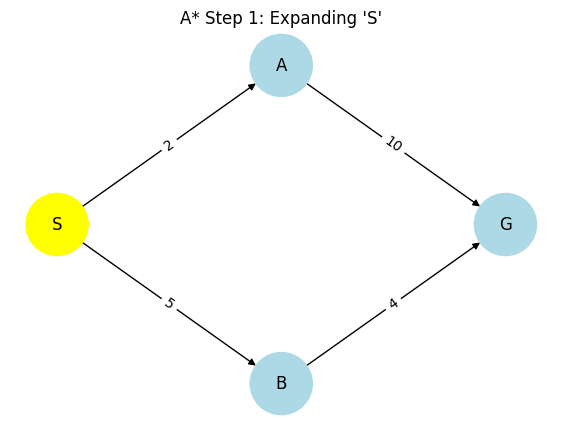

In [ ]:
# STEP-BY-STEP A* SEARCH ANIMATION (JUPYTER-SAFE VERSION)

import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import heapq

# -----------------------------
# Graph and Heuristic
# -----------------------------
graph = {
    'S': [('A', 2), ('B', 5)],
    'A': [('G', 10)],
    'B': [('G', 4)],
    'G': []
}

heuristic = {
    'S': 7,
    'A': 6,
    'B': 2,
    'G': 0
}

pos = {
    'S': (0, 1),
    'A': (1, 2),
    'B': (1, 0),
    'G': (2, 1)
}

# Build NetworkX graph
G = nx.DiGraph()
for u in graph:
    for v, w in graph[u]:
        G.add_edge(u, v, weight=w)

# -----------------------------
# Capture A* expansion order
# -----------------------------
def a_star_trace(start, goal):
    open_list = []
    heapq.heappush(open_list, (heuristic[start], start))
    g_cost = {start: 0}
    parent = {start: None}
    expanded = []

    while open_list:
        _, current = heapq.heappop(open_list)
        expanded.append(current)

        if current == goal:
            break

        for neighbor, cost in graph[current]:
            new_g = g_cost[current] + cost
            if neighbor not in g_cost or new_g < g_cost[neighbor]:
                g_cost[neighbor] = new_g
                parent[neighbor] = current
                heapq.heappush(
                    open_list,
                    (new_g + heuristic[neighbor], neighbor)
                )

    # Reconstruct optimal path
    path = []
    node = goal
    while node:
        path.append(node)
        node = parent.get(node)

    return expanded, path[::-1]

expanded_nodes, optimal_path = a_star_trace('S', 'G')

# -----------------------------
# Animation
# -----------------------------
fig, ax = plt.subplots(figsize=(7, 5))

def update(step):
    ax.clear()

    colors = []
    for node in G.nodes():
        if node == expanded_nodes[step]:
            colors.append('yellow')      # current expansion
        elif node in optimal_path and step == len(expanded_nodes) - 1:
            colors.append('green')       # final optimal path
        else:
            colors.append('lightblue')   # unvisited

    nx.draw(G, pos, with_labels=True,
            node_color=colors,
            node_size=2000,
            ax=ax)

    labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, ax=ax)

    ax.set_title(f"A* Step {step + 1}: Expanding '{expanded_nodes[step]}'")

ani = FuncAnimation(
    fig,
    update,
    frames=len(expanded_nodes),
    interval=1200,
    repeat=False
)

HTML(ani.to_jshtml())

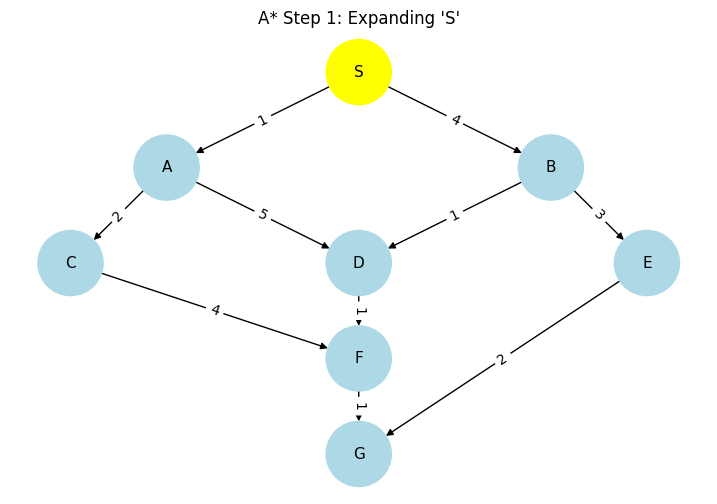

In [ ]:
# STEP-BY-STEP A* SEARCH ANIMATION (LARGER EXAMPLE, JUPYTER-SAFE)

import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import heapq

# -----------------------------
# Larger Graph and Heuristic
# -----------------------------
graph = {
    'S': [('A', 1), ('B', 4)],
    'A': [('C', 2), ('D', 5)],
    'B': [('D', 1), ('E', 3)],
    'C': [('F', 4)],
    'D': [('F', 1)],
    'E': [('G', 2)],
    'F': [('G', 1)],
    'G': []
}

heuristic = {
    'S': 7,
    'A': 6,
    'B': 5,
    'C': 4,
    'D': 3,
    'E': 4,
    'F': 2,
    'G': 0
}

# Fixed positions (tree-like layout)
pos = {
    'S': (0, 4),
    'A': (-2, 3),
    'B': (2, 3),
    'C': (-3, 2),
    'D': (0, 2),
    'E': (3, 2),
    'F': (0, 1),
    'G': (0, 0)
}

# Build NetworkX graph
G = nx.DiGraph()
for u in graph:
    for v, w in graph[u]:
        G.add_edge(u, v, weight=w)

# -----------------------------
# Capture A* expansion order
# -----------------------------
def a_star_trace(start, goal):
    open_list = []
    heapq.heappush(open_list, (heuristic[start], start))
    g_cost = {start: 0}
    parent = {start: None}
    expanded = []

    while open_list:
        _, current = heapq.heappop(open_list)
        expanded.append(current)

        if current == goal:
            break

        for neighbor, cost in graph[current]:
            new_g = g_cost[current] + cost
            if neighbor not in g_cost or new_g < g_cost[neighbor]:
                g_cost[neighbor] = new_g
                parent[neighbor] = current
                heapq.heappush(
                    open_list,
                    (new_g + heuristic[neighbor], neighbor)
                )

    # Reconstruct optimal path
    path = []
    node = goal
    while node:
        path.append(node)
        node = parent.get(node)

    return expanded, path[::-1]

expanded_nodes, optimal_path = a_star_trace('S', 'G')

# -----------------------------
# Animation
# -----------------------------
fig, ax = plt.subplots(figsize=(9, 6))

def update(step):
    ax.clear()

    colors = []
    for node in G.nodes():
        if node == expanded_nodes[step]:
            colors.append('yellow')      # current expansion
        elif node in optimal_path and step == len(expanded_nodes) - 1:
            colors.append('green')       # final optimal path
        else:
            colors.append('lightblue')   # unvisited

    nx.draw(
        G, pos,
        with_labels=True,
        node_color=colors,
        node_size=2200,
        font_size=11,
        ax=ax
    )

    labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, ax=ax)

    ax.set_title(
        f"A* Step {step + 1}: Expanding '{expanded_nodes[step]}'",
        fontsize=12
    )

ani = FuncAnimation(
    fig,
    update,
    frames=len(expanded_nodes),
    interval=1200,
    repeat=False
)

HTML(ani.to_jshtml())


In [ ]:
# Graph representation
graph = {
    'A': [('B', 6), ('F', 3)],
    'B': [('C', 3),('D', 2)],
    '': [('', 4)],
    'G': []
}

heuristic = {
    'S': 7,
    'A': 6,
    'B': 2,
    'G': 0
}

print("Graph and heuristic initialized.")